In [1]:
import warnings
warnings.simplefilter('ignore')

%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'

from pylab import rcParams
rcParams['figure.figsize'] = 8, 5
import pandas as pd

In [2]:
df = pd.read_csv('../data/online_vs_offline_learning_dataset.csv')
df.head()

,Learning_Mode,Subject,Study_Hours,Retention_Score,Focus_Level,Exam_Score
0,Offline,English,7.7,51,96,70
1,Offline,English,6.2,90,82,81
2,Online,English,1.2,75,66,71
3,Online,Math,6.5,80,64,77
4,Online,English,5.5,95,58,78


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Learning_Mode    1000 non-null   str    
 1   Subject          1000 non-null   str    
 2   Study_Hours      1000 non-null   float64
 3   Retention_Score  1000 non-null   int64  
 4   Focus_Level      1000 non-null   int64  
 5   Exam_Score       1000 non-null   int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 60.3 KB


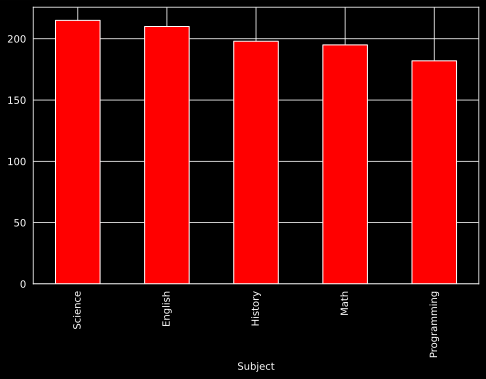

In [9]:
df['Subject'].value_counts().plot(kind='bar', color='red');

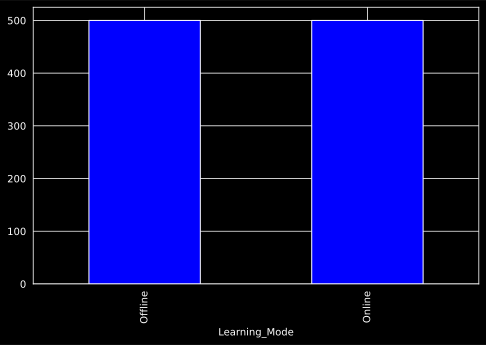

In [8]:
df['Learning_Mode'].value_counts().plot(kind='bar', color='blue');

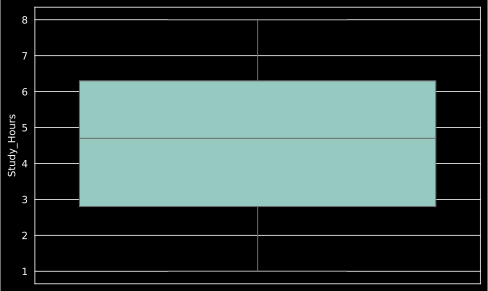

In [10]:
sns.boxplot(df['Study_Hours']);

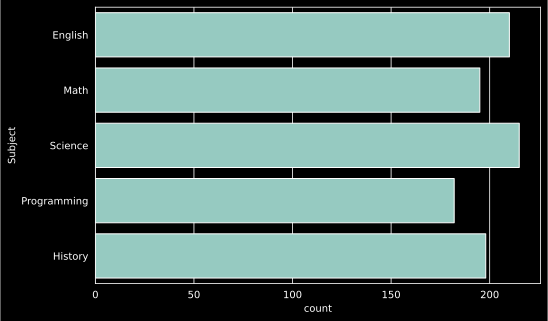

In [11]:
sns.countplot(df['Subject']);

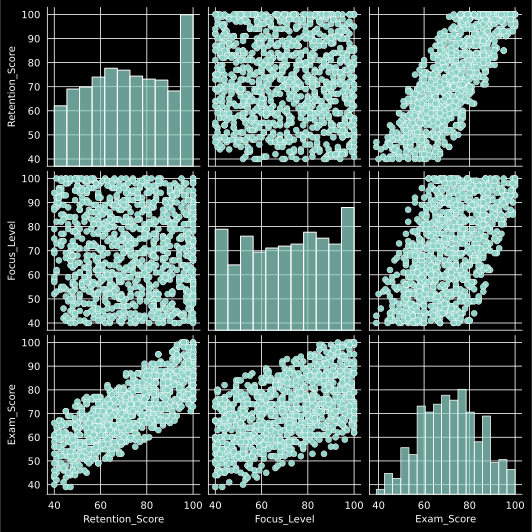

In [12]:
columns = ['Retention_Score', 'Focus_Level', 'Exam_Score']
sns.pairplot(df[columns]);

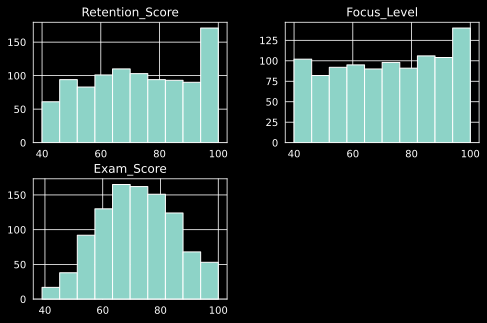

In [14]:
df[columns].hist();

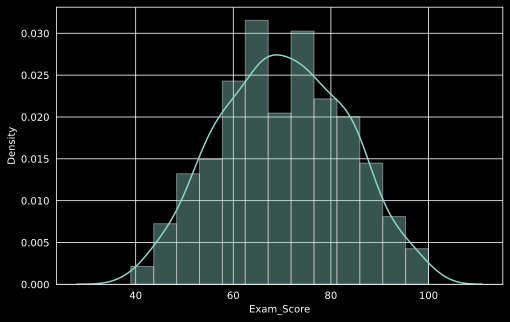

In [33]:
sns.distplot(df[df['Learning_Mode'] == 'Online']['Exam_Score']);

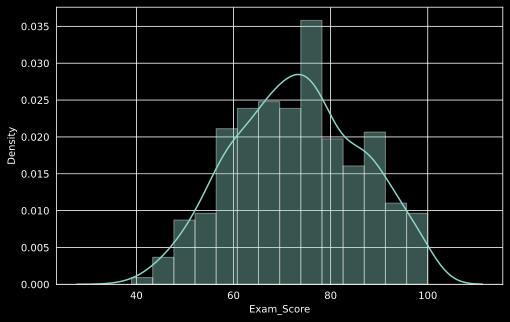

In [34]:
sns.distplot(df[df['Learning_Mode'] == 'Offline']['Exam_Score']);

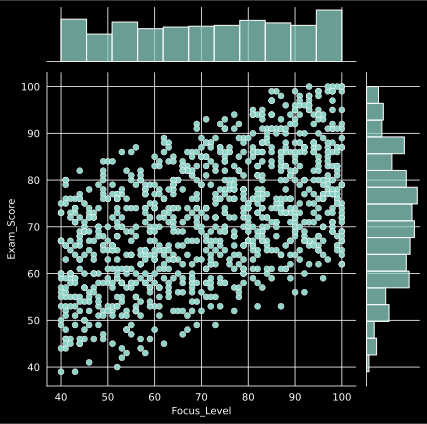

In [19]:
sns.jointplot(x=df['Focus_Level'], y=df['Exam_Score']);

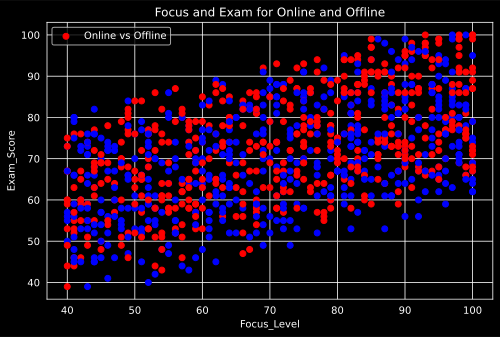

In [23]:
plt.scatter(x=df['Focus_Level'], y=df['Exam_Score'],
            color=df['Learning_Mode'].map({'Offline': 'red', 'Online': 'blue'}),
            label='Online vs Offline');
plt.xlabel('Focus_Level');
plt.ylabel('Exam_Score');
plt.title('Focus and Exam for Online and Offline');
plt.legend();


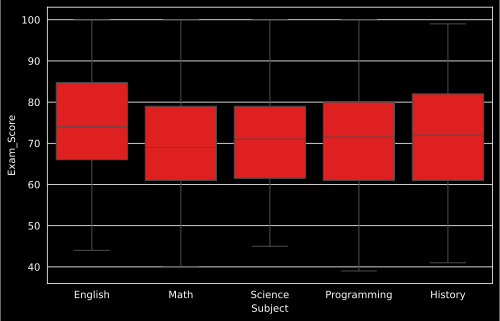

In [38]:
sns.boxplot(x='Subject', y='Exam_Score', data=df, color='red');

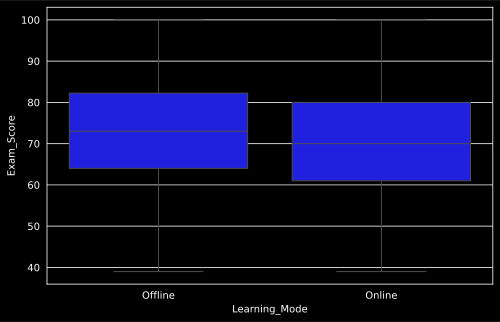

In [39]:
sns.boxplot(x='Learning_Mode', y='Exam_Score', data=df, color='blue');

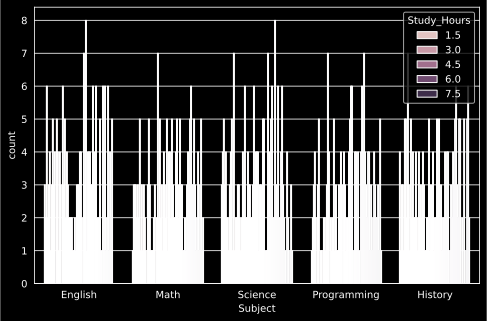

In [46]:
sns.countplot(x='Subject', hue='Study_Hours', data=df);

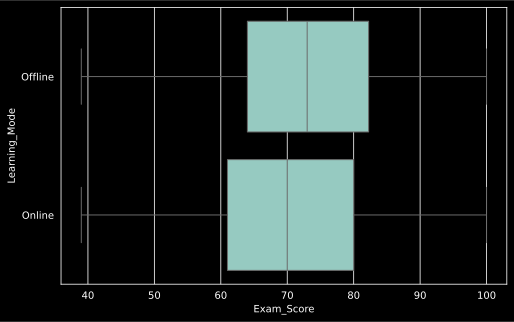

In [51]:
mode = df['Learning_Mode'].value_counts().sort_index(ascending=True).head().index
sns.boxplot(x='Exam_Score', y='Learning_Mode', data=df[df.Learning_Mode.isin(mode)], showfliers=False, orient='h');

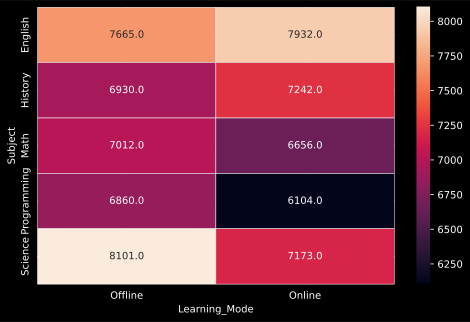

In [53]:
df_heatmap = df.pivot_table(
    index='Subject',
    columns='Learning_Mode',
    values='Exam_Score',
    aggfunc=sum)
sns.heatmap(df_heatmap, annot=True, fmt='.1f', linewidths=.5);

In [54]:
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly
import plotly.graph_objs as go

init_notebook_mode(connected=True)

In [56]:
study_for_result = df.groupby('Study_Hours')[['Focus_Level']].mean().join(
    df.groupby('Study_Hours')[['Exam_Score']].mean()
)

trace0 = go.Scatter(
    x=study_for_result.index,
    y=study_for_result.Focus_Level,
    name='Focus'
)

trace1 = go.Scatter(
    x=study_for_result.index,
    y=study_for_result.Exam_Score,
    name='Exam'
)

data = [trace0, trace1]
layout = {'title': 'study_for_result'}

fig = go.Figure(data=data, layout=layout)
iplot(fig, show_link=False);

In [61]:
study_for_result = df.groupby('Study_Hours')[['Focus_Level']].mean().join(
    df.groupby('Study_Hours')[['Retention_Score']].mean()
)

trace0 = go.Bar(
    x=study_for_result.index,
    y=study_for_result.Focus_Level,
    name='Focus'
)

trace1 = go.Bar(
    x=study_for_result.index,
    y=study_for_result.Retention_Score,
    name='Retention'
)

data = [trace0, trace1]
layout = {'title': 'study_for_result'}

fig = go.Figure(data=data, layout=layout)
iplot(fig, show_link=False);

In [63]:
data = []

for sbjct in df.Subject.unique():
    data.append(go.Box(y=df[df.Subject == sbjct].Exam_Score, name=sbjct))

iplot(data, show_link=False);